In [1]:
import numpy as np
import random
import functools
import yaml
import os
from deap import gp
from alpine.gp.gpsymbreg import GPSymbolicRegressor
import warnings
import ray
from sympy import symbols, lambdify, sin, sqrt, pprint, latex, cos, tanh
from IPython.display import display, Math
from ControllerComp import V_x, f, x, G, Q, R, safe_divideSR, compute_v_and_v_dot2

from Fitness import fitness
from PredictScoreFuncs import predict, score
import Functions
from SymFunctions import read_expression, DeapSimplifier
from V_Vdot_Calculations import compute_v_and_v_dot

import matplotlib.pyplot as plt

In [2]:
# Define the numerical grid (Domain)
x1_vals = np.linspace(-2, 2, 100)
x2_vals = np.linspace(-2, 2, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

In [3]:

def main():
    yamlfile = "Lyapunov.yaml"
    filename = yamlfile
    with open(filename) as config_file:
        config_file_data = yaml.safe_load(config_file)

    pset = gp.PrimitiveSetTyped(
        "MAIN",
        [
            float, float
        ],
        float,
    )
    
    pset.renameArguments(ARG0="x1", ARG1="x2")
    
    #pset.addPrimitive(one_minus_cos, (float,), float)

    #def random_constant():
    #    return random.uniform(-10, 10)

    #pset.addEphemeralConstant("rand", functools.partial(random_constant), float)

    #pset.addEphemeralConstant("rand", lambda: random.uniform(-10, 10), float)
    #pset.addTerminal(1, float) 
    
    penalty = config_file_data["gp"]["penalty"]
    common_data = {"penalty": penalty}

    gpsr = GPSymbolicRegressor(
        pset=pset,
        fitness=fitness.remote,
        error_metric=score.remote,
        predict_func=predict.remote,
        common_data=common_data,
        config_file_data=config_file_data,
        print_log=True,
        batch_size=100,
    )

    train_data = Functions.Dataset("true_data", [x1_vals, x2_vals], None)
    gpsr.fit(train_data)

    # Access and save the best individual
    best_expression = gpsr.best  # Save the best expression
    best_fitness = gpsr.train_fit_history[-1]  # Save the best fitness score

    # Write best expression to a file
    with open("best_expression.txt", "w") as file:
        file.write(f"Best Expression:\n{best_expression}\n")
        file.write(f"Best Fitness:\n{best_fitness}\n")

    print("Best Expression and Fitness saved to 'best_expression.txt'.")

    ray.shutdown()


if __name__ == "__main__":
    main()


2025-02-12 19:35:12,446	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Generating initial population(s)...
DONE.
 -= START OF EVOLUTION =- 
Evaluating initial population(s)...


(fitness pid=212373) <lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in scalar divide
(fitness pid=212373)   return array([[0], [(2*x2 - 2)*((2 - 2*x2)*(-2.66666666666667*x2 + 19.62*sin(x1)) + 19.62*sqrt(0.00259777775699556*(2 - 2*x2)**2*(x1**2 + x2**2) + (2 - 2*x2)**2*(-0.135915732246007*x2 + sin(x1))**2))/(2 - 2*x2)**2]])
(fitness pid=212374)   return array([[0], [(x1*(2*x2 - 1) - 1)*(x2*(2*x1 - x2**2 + x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1*(2*x2 - 1) + 1) + sqrt((x1**2 + x2**2)*(-x1*(2*x2 - 1) + 1)**2 + (x2*(2*x1 - x2**2 + x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1*(2*x2 - 1) + 1))**2))/(-x1*(2*x2 - 1) + 1)**2]])
(fitness pid=212374) <lambdifygenerated-147>:2: RuntimeWarning: invalid value encountered in scalar divide
(fitness pid=212373) <lambdifygenerated-150>:2: RuntimeWarning: invalid value encountered in scalar divide
(fitness pid=212373)   return array([[0], [(x2*(-6*x1**2 - 2*x1*x2**2 - 12*x1*(x1 - x2) + x2 + 1) + (-2.66666666666667*x2 + 

RayTaskError(KeyError): [36mray::fitness()[39m (pid=212373, ip=172.30.223.238)
  File "/home/ali1377/AlpineSRCLF/AlpineGP/SymCLF-Copy3/Fitness.py", line 29, in fitness
    if MSEE[i] > 10e9:
KeyError: 45

(fitness pid=212374) [100000020001.0, 100495510050.51852, 100211611422.12701, inf, 100098775794.70583, 5667138635210.641, 273668107513.54358, 100000007036.95752, 100000037948.98033, 100000005565.39894, 100000423278.297, 100115866501.16989, 100000009757.37392, 100000064753.33366, inf, 100001657254.54361, 100000782705.73758, inf, 100001175826.12474, 100000020001.0, 100306005712.06656, 7310788781196.343, 100004728019.80652, 100000025974.64557, 100009146511.03354, 100000009825.55984, 100000012378.1788, 100041496028.55295, 100000005343.84935, 100010631438.18217, 1540766314265.7378, 100000010101.25143, 100000009742.7542, 100000020001.0, 100001879850.71481, 100001644665.00275, 100000007556.96066, 100022456632.13942, 100007950794.47308, 100004182313.73514, 5513143151060.681, 100053285756.3838, 100000009752.103, 101927879905.43141, 100000006457.42357, inf, 100002716452.99054, 100000010128.64104, inf, 107882061907.15678, 100000020001.0, 100000020001.0, 1509743656572.1953, 192876218170.70935, 142

In [3]:
expression = read_expression("best_expression20.txt") #+ '+ 73'
#read_expression("best_expression.txt") #+ '+ 73'
#'0.01875 * x2**2 + 0.73575 * (1 - cos(x1))'
#'x1**2 + x2**2'

simplified_expr = DeapSimplifier(expression)
display(Math(latex(simplified_expr)))

Original Expression: add(add(add(mul(add(x1, mul(sub(sub(x1, x2), add(x1, mul(sub(add(sub(x2, mul(mul(x1, x2), x1)), x2), x2), x2))), sub(x2, x2))), add(add(x1, x1), add(x1, add(x2, add(add(x1, x1), x1))))), mul(add(sub(x2, mul(mul(x1, x1), x1)), x2), add(x2, x1))), mul(x2, x2)), mul(add(add(x1, x1), add(x1, add(x1, add(x1, add(x1, add(x2, add(x1, x1))))))), add(add(x2, x1), x1)))
Simplified Expression: x1*(6*x1 + x2) + x2**2 + (x1 + x2)*(-x1**3 + 2*x2) + (2*x1 + x2)*(8*x1 + x2)


<IPython.core.display.Math object>

In [4]:
# Define symbolic variables
x1, x2 = symbols('x1 x2')
V_func = lambdify((x1, x2), simplified_expr, modules='numpy')
V_vals = V_func(X1, X2)

In [5]:
print(x1_vals.shape)

(100,)


In [6]:
_, V_grad_mag, V_dot_vals, lambda_vals, u_vals, u_vals2, u_mag = compute_v_and_v_dot(V_vals, x1_vals, x2_vals)

In [7]:
V_violations = np.count_nonzero(V_vals < 0)
print(V_violations)

Vdot_violations = np.count_nonzero(V_dot_vals > 0)
print(Vdot_violations)

0
0


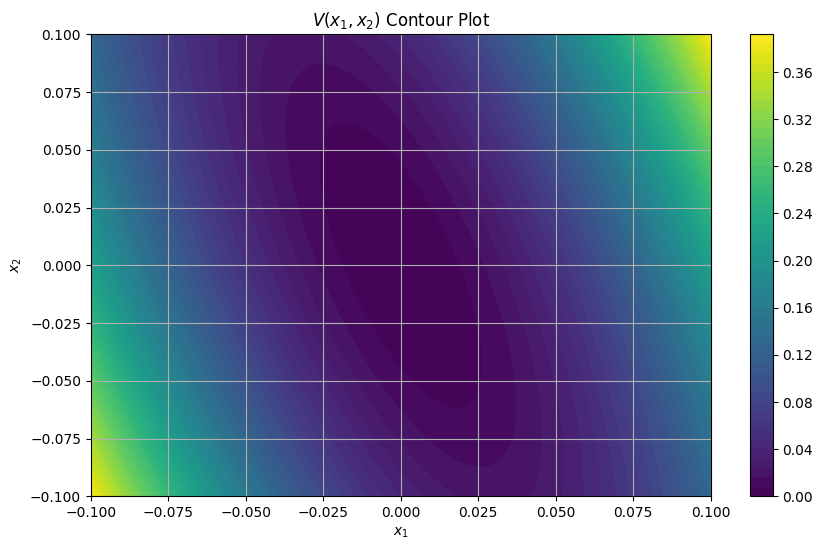

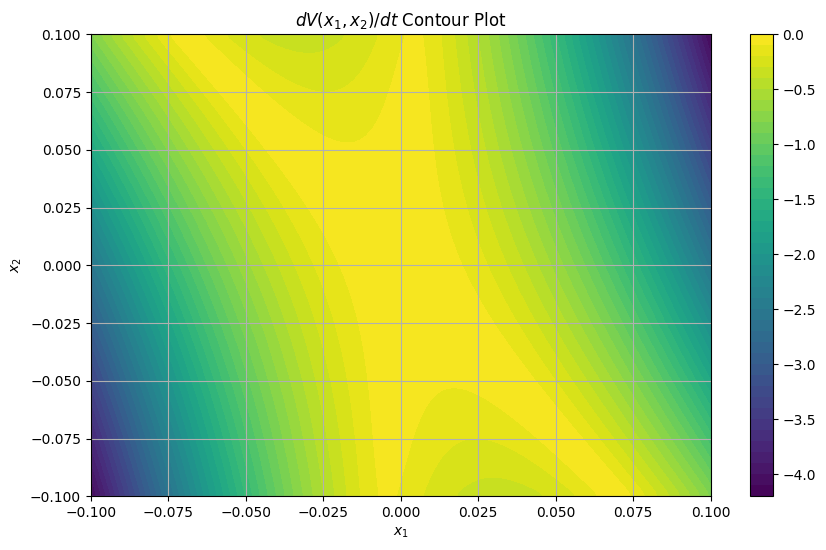

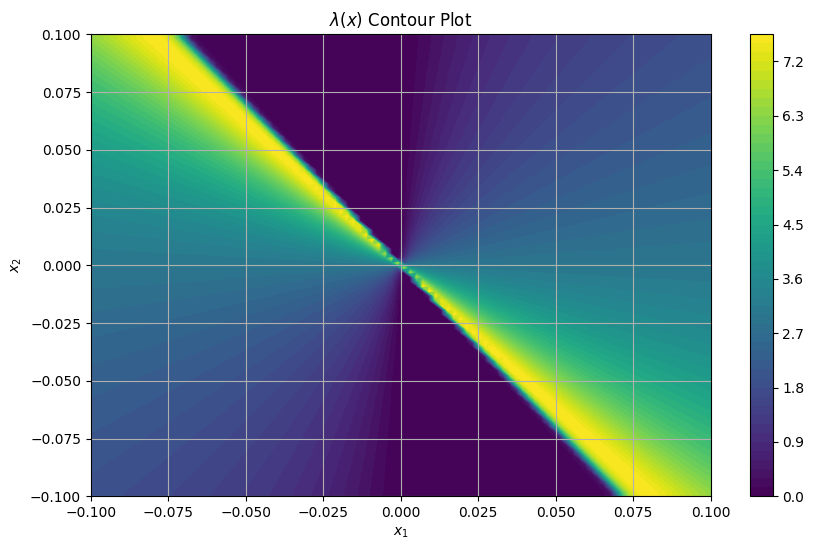

mean value of lambda:
2.4969446514374907


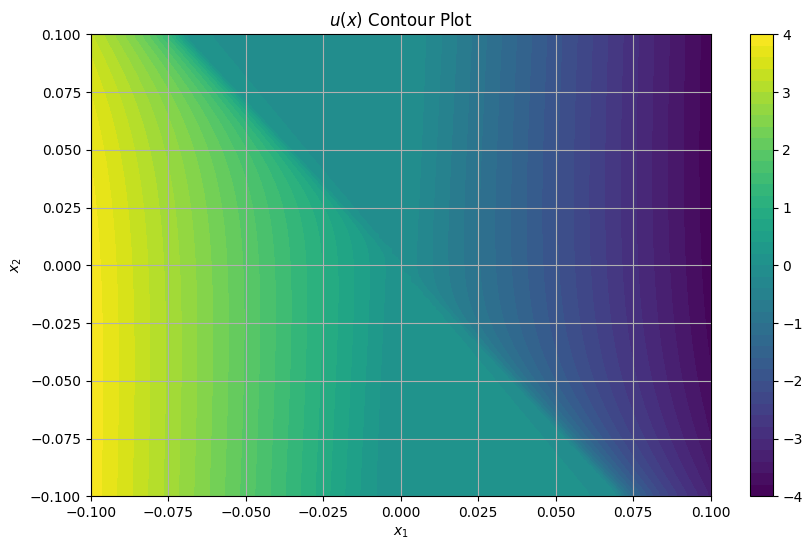

2.2737367544323206e-16


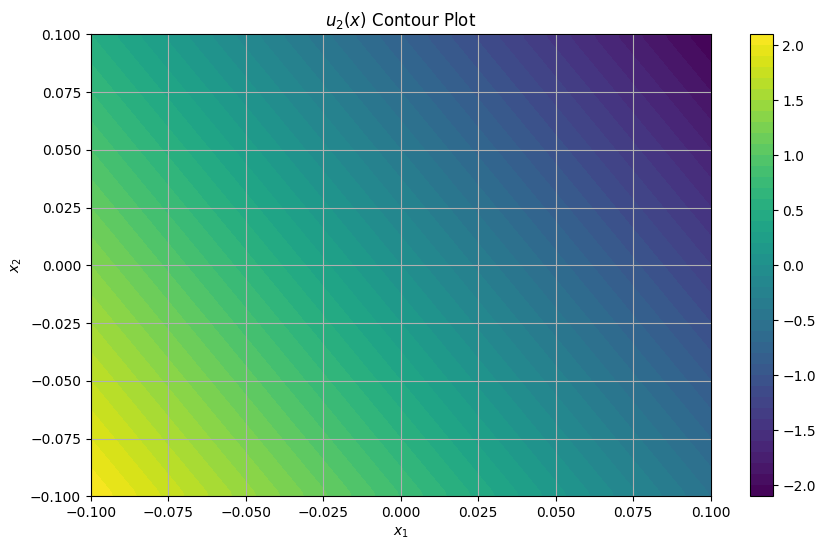

In [8]:
import matplotlib.pyplot as plt

X1 = x1_vals
X2 = x2_vals

# Plot V(x1, x2)
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$V(x_1, x_2)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of V_x1
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_dot_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$d V(x_1, x_2) / dt$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of lambda_x
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, lambda_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$\lambda(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

print('mean value of lambda:')
print(np.mean(lambda_vals))

# Plot the contour of u
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()
#levels=np.linspace(-10, 10, 50)
print(np.mean(u_vals))

# Plot the contour of u2
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals2, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u_2(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

In [9]:
V = simplified_expr
x1, x2 = symbols('x1 x2')
V_grad = V_x(V, x1, x2)
x_vector = x(x1, x2)
f_vector = f(x1, x2)
G_matrix = G(x1, x2)
Q_matrix = Q(x1, x2)
R_matrix = R(x1, x2)

V_func, V_dot_func, lambda_func, u_func, u_func2, u_mag, b_norm_squared = compute_v_and_v_dot2(V)

print(u_func)
u_func

(x1**3 - 13*x1 - 8*x2)*(x2*(-x1**3 - 3*x1**2*(x1 + x2) + 44*x1 + 13*x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1**3 + 13*x1 + 8*x2) + sqrt((x1**2 + x2**2)*(-x1**3 + 13*x1 + 8*x2)**2 + (x2*(-x1**3 - 3*x1**2*(x1 + x2) + 44*x1 + 13*x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1**3 + 13*x1 + 8*x2))**2))/(-x1**3 + 13*x1 + 8*x2)**2


(x1**3 - 13*x1 - 8*x2)*(x2*(-x1**3 - 3*x1**2*(x1 + x2) + 44*x1 + 13*x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1**3 + 13*x1 + 8*x2) + sqrt((x1**2 + x2**2)*(-x1**3 + 13*x1 + 8*x2)**2 + (x2*(-x1**3 - 3*x1**2*(x1 + x2) + 44*x1 + 13*x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1**3 + 13*x1 + 8*x2))**2))/(-x1**3 + 13*x1 + 8*x2)**2

In [10]:
b_norm_squared

(-x1**3 + 13*x1 + 8*x2)**2

In [11]:
print(V_dot_func)

x2*(-x1**3 - 3*x1**2*(x1 + x2) + 44*x1 + 13*x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1**3 + 13*x1 + 8*x2) + (x1**3 - 13*x1 - 8*x2)*(x2*(-x1**3 - 3*x1**2*(x1 + x2) + 44*x1 + 13*x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1**3 + 13*x1 + 8*x2) + sqrt((x1**2 + x2**2)*(-x1**3 + 13*x1 + 8*x2)**2 + (x2*(-x1**3 - 3*x1**2*(x1 + x2) + 44*x1 + 13*x2) + (-2.66666666666667*x2 + 19.62*sin(x1))*(-x1**3 + 13*x1 + 8*x2))**2))/(-x1**3 + 13*x1 + 8*x2)


In [12]:
from sympy import symbols, Function, Matrix, Eq, dsolve
#from SystemDynamics import f, G, Q, R
from NumSol import NumSol
import matplotlib.pyplot as plt

In [13]:
x1, x2 = symbols('x1 x2')

from sympy import symbols, lambdify, diff, Matrix, sin, cos, exp, log, sqrt, tanh

#u_func = -0.025467670686794*x1 - 0.19026288312708*x2
#u_func = 20 * tanh(-23.28 * x1 + -5.27 * x2)
#u_func = (-73*x1 - 40*x2)*(sqrt((73*x1 + 40*x2)**2*(x1**2 + x2**2) + (x2*(126*x1 + 73*x2) + (73*x1 + 40*x2)*(0.666666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(126*x1 + 73*x2) + (73*x1 + 40*x2)*(0.666666666666667*x2 - 19.62*sin(x1)))/(73*x1 + 40*x2)**2)
#u_func = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)

T = 40
x1_0, x2_0 = 0.1, 0.1
#3,0 #-3, -3#-2.5, 0#1, 1# 4, 0
#t_vals, x1_vals, x2_vals = NumSol(u_func, T, x1_0, x2_0)

In [14]:
u_func_LQR = -39.265*x1 - 6.641*x2
t_vals_L, x1_vals_L, x2_vals_L = NumSol(u_func_LQR, T, x1_0, x2_0, None)

u_func_NN = 20 * tanh(-23.28 * x1  -5.27 * x2)/0.0375
t_vals_N, x1_vals_N, x2_vals_N = NumSol(u_func_NN, T, x1_0, x2_0, None)

#u_func_CLF = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)
u_func_CLF = u_func
t_vals_C, x1_vals_C, x2_vals_C = NumSol(u_func_CLF, T, x1_0, x2_0, b_norm_squared)


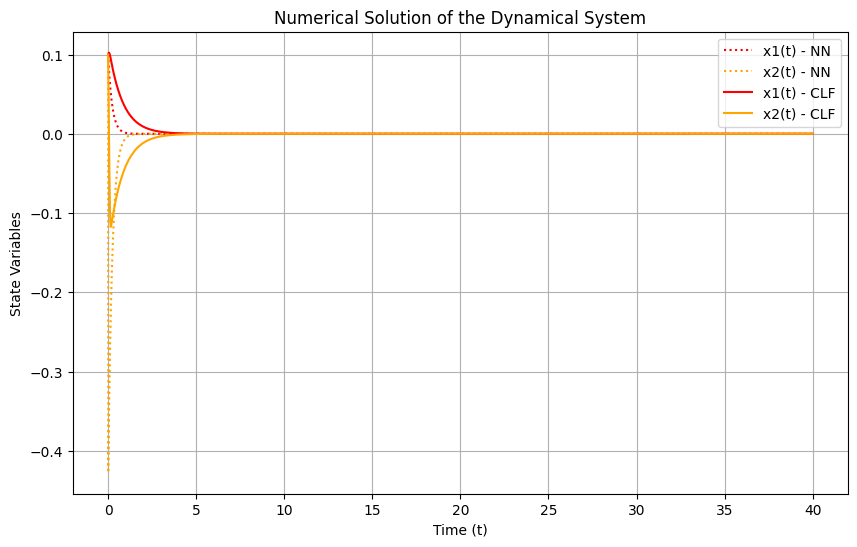

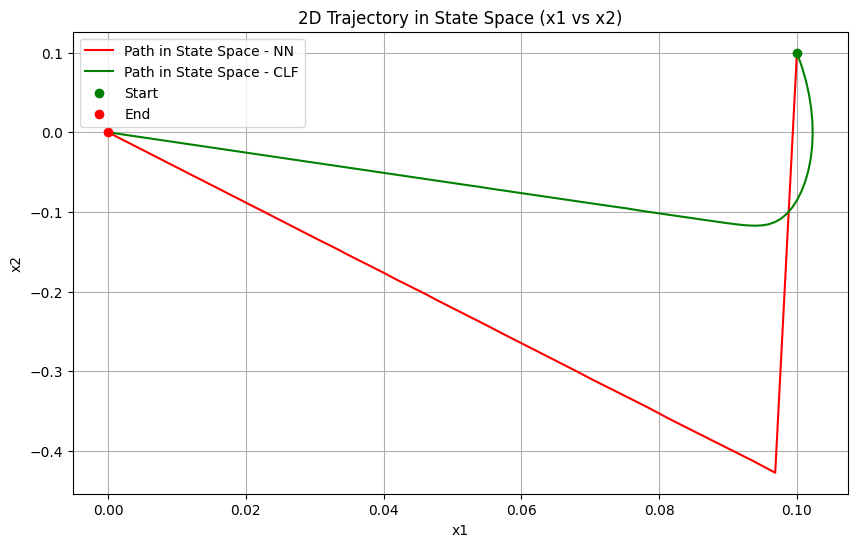

In [15]:
# Plot the solution
plt.figure(figsize=(10, 6))

#plt.plot(t_vals_L, x1_vals_L, label="x1(t) - LQR", color="red", linestyle='--')
#plt.plot(t_vals_L, x2_vals_L, label="x2(t) - LQR", color="orange", linestyle='--')

plt.plot(t_vals_N, x1_vals_N, label="x1(t) - NN", color="red", linestyle=':')
plt.plot(t_vals_N, x2_vals_N, label="x2(t) - NN", color="orange", linestyle=':')

plt.plot(t_vals_C, x1_vals_C, label="x1(t) - CLF", color="red")
plt.plot(t_vals_C, x2_vals_C, label="x2(t) - CLF", color="orange")
'''
plt.plot(time[0:10], x_list[0:10, 0], label="x1(t) - MCP", color="red", linestyle='-.')
plt.plot(time[0:10], x_list[0:10, 1], label="x2(t) - MPC", color="orange", linestyle='-.')
'''
plt.xlabel("Time (t)")
plt.ylabel("State Variables")
plt.legend()
plt.title("Numerical Solution of the Dynamical System")
plt.grid()
plt.show()


# Plot the 2D trajectory (state space path)
plt.figure(figsize=(10, 6))

#plt.plot(x1_vals_L, x2_vals_L, label="Path in State Space - LQR", color="purple")
plt.plot(x1_vals_N, x2_vals_N, label="Path in State Space - NN", color="red")
plt.plot( x1_vals_C, x2_vals_C, label="Path in State Space - CLF", color="green")
'''
plt.plot(x_list[:, 0], x_list[:, 1], label="Path in State Space - MPC", color="b")
'''
plt.scatter(x1_0, x2_0, color="green", label="Start", zorder=5)  # Start point
plt.scatter(0, 0, color="red", label="End", zorder=5)  # End point

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Trajectory in State Space (x1 vs x2)")
plt.legend()
plt.grid()
plt.show()

In [16]:
from CostFunction import calculate_cost

# Calculate the cost
cost_LQR, cost_LQR1, cost_LQR2, u_val_LQR = calculate_cost(t_vals_L, x1_vals_L, x2_vals_L, u_func_LQR, None, 0)
print("Total cost for LQR:", cost_LQR, cost_LQR1, cost_LQR2)

cost_NN, cost_NN1, cost_NN2, u_val_NN = calculate_cost(t_vals_N, x1_vals_N, x2_vals_N, u_func_NN, None, 0)
print("Total cost for NN:", cost_NN, cost_NN1, cost_NN2)

cost_CLF, cost_CLF1, cost_CLF2, u_val_CLF = calculate_cost(t_vals_C, x1_vals_C, x2_vals_C, u_func_CLF, b_norm_squared, 0)
print("Total cost for CLF:", cost_CLF, cost_CLF1, cost_CLF2)

Total cost for LQR: [[3.28355104]] 0.014620111649058078 [[3.26893093]]
Total cost for NN: [[2246.35456507]] 0.022690694316617303 [[2246.33187437]]
Total cost for CLF: [[3.58368836]] 0.011633138219191888 [[3.57205523]]


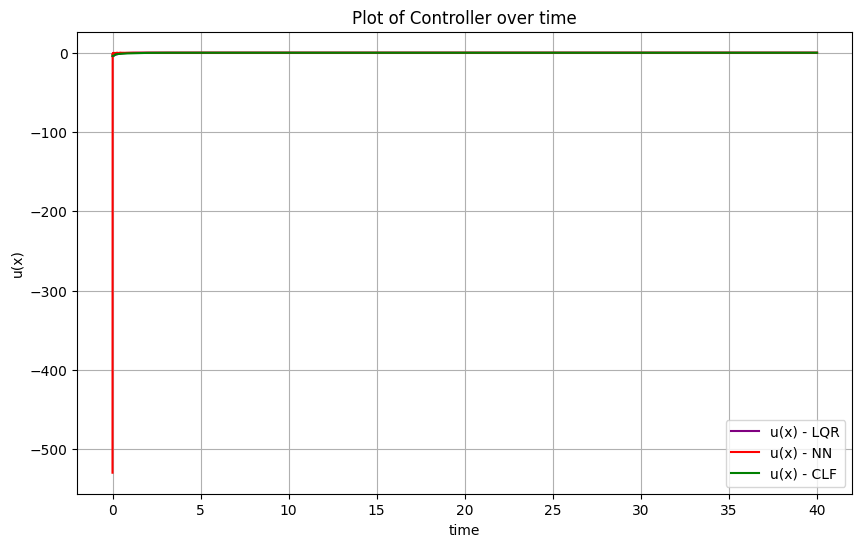

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals_C[0:], u_val_LQR[0:, 1], label="u(x) - LQR", color="purple")
plt.plot(t_vals_C[0:], u_val_NN[0:, 1], label="u(x) - NN", color="red")
plt.plot(t_vals_C[0:], u_val_CLF[0:, 1], label="u(x) - CLF", color="green")
plt.xlabel("time")
plt.ylabel("u(x)")
plt.title("Plot of Controller over time")
plt.legend()
plt.grid()
plt.show()

In [20]:
x2_vals_C[-1]

-8.639718624310969e-06